# Proyecto 1 
 Juan Camilo Gómez-202220238
 
 Jerónimo Rueda-202223775

### Librerias


In [195]:
   
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns  

## Datos

In [196]:
df = pd.read_csv("Saber 11 Datos Valle.csv")


mapaarreglo = {
    "Sin Estrato": 0,
    "Estrato 1": 1,
    "Estrato 2": 2,
    "Estrato 3": 3,
    "Estrato 4": 4,
    "Estrato 5": 5,
    "Estrato 6": 6
}

df["estrato_num"] = df["fami_estratovivienda"].map(mapaarreglo)


#df[df["fami_estratovivienda"]=="Sin Estrato"][["estrato_num", "fami_estratovivienda"]].head()

df[df["punt_lectura_critica"].isna()]["periodo"].value_counts()

df=df[df["punt_global"].notna()]
df=df.drop_duplicates()


### Atributos

In [197]:
df.shape
print(df["estrato_num"].value_counts())
print(df["fami_estratovivienda"].value_counts())

estrato_num
2.0    104220
1.0     82249
3.0     62330
4.0     17485
5.0     10198
6.0      4542
0.0      2589
Name: count, dtype: int64
fami_estratovivienda
Estrato 2      104220
Estrato 1       82249
Estrato 3       62330
Estrato 4       17485
Estrato 5       10198
Estrato 6        4542
Sin Estrato      2589
Name: count, dtype: int64


# Descripción Breve Estadística

In [198]:
df.describe()

,periodo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,estrato_num
count,295188.000000,2.950260e+05,2.951880e+05,295188.0,295188.000000,295188.000000,295160.000000,295160.000000,294916.000000,294916.000000,295090.000000,295188.000000,295188.000000,295188.000000,295188.000000,295188.000000,283613.000000
mean,20176.114449,2.646067e+11,2.652561e+11,76.0,76204.152106,142728.089468,75.808507,76004.316439,75.797115,75999.431648,51.639849,50.880432,50.135551,50.967343,52.966801,256.342155,2.206743
std,27.183082,9.818259e+10,9.830528e+10,0.0,288.723321,187126.016440,3.334391,3346.286244,3.419940,3427.060370,12.666649,11.943208,11.653442,10.731520,10.282470,50.313048,1.153260
min,20142.000000,1.760010e+11,1.760010e+11,76.0,76001.000000,16659.000000,5.000000,5001.000000,5.000000,5001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20152.000000,1.761090e+11,1.761090e+11,76.0,76001.000000,24364.000000,76.000000,76001.000000,76.000000,76001.000000,43.000000,42.000000,42.000000,43.000000,46.000000,219.000000,1.000000
50%,20172.000000,1.768690e+11,1.768900e+11,76.0,76001.000000,95042.000000,76.000000,76001.000000,76.000000,76001.000000,50.000000,50.000000,50.000000,51.000000,53.000000,253.000000,2.000000
75%,20194.000000,3.760010e+11,3.760010e+11,76.0,76364.000000,140509.000000,76.000000,76318.000000,76.000000,76364.000000,58.000000,59.000000,58.000000,58.000000,60.000000,290.000000,3.000000
max,20224.000000,5.376109e+11,5.376110e+11,76.0,76895.000000,806752.000000,99.000000,99524.000000,97.000000,97161.000000,100.000000,100.000000,100.000000,100.000000,100.000000,495.000000,6.000000


In [199]:
df.info()
colegios=df.groupby("cole_cod_dane_sede").describe()


<class 'pandas.core.frame.DataFrame'>
Index: 295188 entries, 0 to 642590
Data columns (total 52 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   periodo                        295188 non-null  int64  
 1   estu_tipodocumento             295188 non-null  object 
 2   estu_consecutivo               295188 non-null  object 
 3   cole_area_ubicacion            295183 non-null  object 
 4   cole_bilingue                  262817 non-null  object 
 5   cole_calendario                295188 non-null  object 
 6   cole_caracter                  290311 non-null  object 
 7   cole_cod_dane_establecimiento  295026 non-null  float64
 8   cole_cod_dane_sede             295188 non-null  float64
 9   cole_cod_depto_ubicacion       295188 non-null  int64  
 10  cole_cod_mcpio_ubicacion       295188 non-null  int64  
 11  cole_codigo_icfes              295188 non-null  float64
 12  cole_depto_ubicacion           2951

## Faltantes

In [200]:
df[["cole_cod_mcpio_ubicacion","estrato_num"]].groupby("cole_cod_mcpio_ubicacion").value_counts()
prom_estrato=(df.groupby("cole_cod_mcpio_ubicacion")["estrato_num"].transform("mean").round())

df["estrato_num"] = df["estrato_num"].fillna(prom_estrato).astype("Int64")
df["fami_estratovivienda"]=df["fami_estratovivienda"].fillna("Estrato"+prom_estrato.astype("string")).astype("string")

#print(prom_estrato)

#df[df["cole_bilingue"].isna()].describe()
#df[["cole_bilingue","estrato_num"]].groupby("cole_bilingue").value_counts()
df["cole_bilingue"] = df["cole_bilingue"].fillna("Desconocido")
df["cole_caracter"] = df["cole_caracter"].fillna("Desconocido")
df["cole_cod_dane_establecimiento"] = df["cole_cod_dane_establecimiento"].fillna("Desconocido (Instituto Tecnológico Gran Colombia)")
df["cole_area_ubicacion"] = df["cole_area_ubicacion"].fillna("RURAL")
df["cole_cod_dane_establecimiento"] = df["cole_area_ubicacion"].fillna("RURAL")
df["estu_cod_depto_presentacion"] = df["estu_cod_depto_presentacion"].fillna(df["estu_cod_reside_depto"])
df["estu_depto_presentacion"] = df["estu_depto_presentacion"].fillna(df["estu_depto_reside"])

df["estu_cod_mcpio_presentacion"] = df["estu_cod_mcpio_presentacion"].fillna(df["estu_cod_reside_mcpio"])
df["estu_cod_reside_depto"] = df["estu_cod_reside_depto"].fillna(df["cole_depto_ubicacion"])
df["estu_cod_reside_mcpio"] = df["estu_cod_reside_mcpio"].fillna(df["cole_mcpio_ubicacion"])
df["estu_depto_reside"] = df["estu_depto_reside"].fillna(df["estu_depto_presentacion"])
df["estu_genero"] = df["estu_genero"].fillna("Desconocido")
df["estu_mcpio_presentacion"] = df["estu_mcpio_presentacion"].fillna(df["cole_mcpio_ubicacion"])
df["estu_mcpio_reside"] = df["estu_mcpio_reside"].fillna(df["cole_mcpio_ubicacion"])

df["fami_cuartoshogar"] = df["fami_cuartoshogar"].fillna("Desconocido")
df["fami_educacionmadre"] = df["fami_educacionmadre"].fillna("Desconocido")
df["fami_educacionpadre"] = df["fami_educacionpadre"].fillna("Desconocido")
df["fami_personashogar"] = df["fami_personashogar"].fillna("Desconocido")
df["fami_tieneautomovil"] = df["fami_tieneautomovil"].fillna("No")
df["fami_tienecomputador"] = df["fami_tienecomputador"].fillna("No")
df["fami_tieneinternet"] = df["fami_tieneinternet"].fillna(df["fami_tienecomputador"])
df["fami_tienelavadora"] = df["fami_tienelavadora"].fillna("No")




#df[df["cole_area_ubicacion"].isna()].head()
#df[["cole_cod_dane_establecimiento","cole_cod_mcpio_ubicacion"]]["cole_cod_dane_establecimiento"].isna().groupby(df["cole_cod_mcpio_ubicacion"]).value_counts()
#df[df["cole_cod_dane_establecimiento"].isna()]["cole_nombre_establecimiento"].value_counts()
df[df["desemp_ingles"].isna()]["estrato_num"].value_counts()
#df["fami_tienecomputador"].value_counts()

df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]
x=df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_matematicas"]+df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_lectura_critica"]+df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_global"]
reemplazaringles=round((df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_matematicas"]/x)*df["punt_matematicas"]+(df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_lectura_critica"]/x)*df["punt_lectura_critica"]+((df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_global"]/5)/x)*df["punt_global"],0)
#print(reemplazaringles

df["punt_ingles"] = df["punt_ingles"].fillna(reemplazaringles)


df[df["desemp_ingles"].isna()]["punt_ingles"].describe()



"""
if df["punt_ingles"]<27:

    df["desemp_ingles"]=df["desemp_ingles"].fillna("A1")

elif df["punt_ingles"]<=40:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("A2")
elif df["punt_ingles"]<55:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B1")
else:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B+")
"""

condiciones = [
    df["punt_ingles"] < 27,
    df["punt_ingles"] <= 40,
    df["punt_ingles"] < 55]
valores = ["A1", "A2", "B1"]
#df["desemp_ingles"].value_counts()

nivel_calc = np.select(condiciones, valores, default="B+")

# Solo llenar faltantes en desemp_ingles
df["desemp_ingles"] = df["desemp_ingles"].fillna(pd.Series(nivel_calc, index=df.index))

df.isna().sum()
categorias= df.columns.tolist()
df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'CALI': 76001}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'GUADALAJARA DE BUGA': 76111}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'BUGALAGRANDE': 76113}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'EL CERRITO': 76248}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'JAMUNDÍ': 76364}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'YUMBO': 76892}, inplace=True)


C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_11116\3839968203.py:84: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
C:\Users\Juan Camilo Gómez\AppData\Local\Temp\ipykernel_11116\3839968203.py:84: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downca

## Columnas y Ejemplo

In [201]:
columnas=df.columns
for i in columnas:
    print(f"Columna:{i} , Ejemplo: {df[i][2]}")


Columna:periodo , Ejemplo: 20224
Columna:estu_tipodocumento , Ejemplo: TI
Columna:estu_consecutivo , Ejemplo: SB11202240151458
Columna:cole_area_ubicacion , Ejemplo: URBANO
Columna:cole_bilingue , Ejemplo: N
Columna:cole_calendario , Ejemplo: A
Columna:cole_caracter , Ejemplo: TÉCNICO/ACADÉMICO
Columna:cole_cod_dane_establecimiento , Ejemplo: URBANO
Columna:cole_cod_dane_sede , Ejemplo: 176364001313.0
Columna:cole_cod_depto_ubicacion , Ejemplo: 76
Columna:cole_cod_mcpio_ubicacion , Ejemplo: 76364
Columna:cole_codigo_icfes , Ejemplo: 671156.0
Columna:cole_depto_ubicacion , Ejemplo: VALLE
Columna:cole_genero , Ejemplo: MIXTO
Columna:cole_jornada , Ejemplo: UNICA
Columna:cole_mcpio_ubicacion , Ejemplo: JAMUNDÍ
Columna:cole_naturaleza , Ejemplo: OFICIAL
Columna:cole_nombre_establecimiento , Ejemplo: INSTITUCION EDUCATIVA TÉCNICA INDUSTRIAL ESPAÑA
Columna:cole_nombre_sede , Ejemplo: TÉCNICA INDUSTRIAL ESPAÑA-SEDE PRINCIPAL
Columna:cole_sede_principal , Ejemplo: S
Columna:estu_cod_depto_pres

# Gráficos de una Variable


### Puntajes

Hay algunas categorias que tienen datos que pasan 100 o son menores que 0

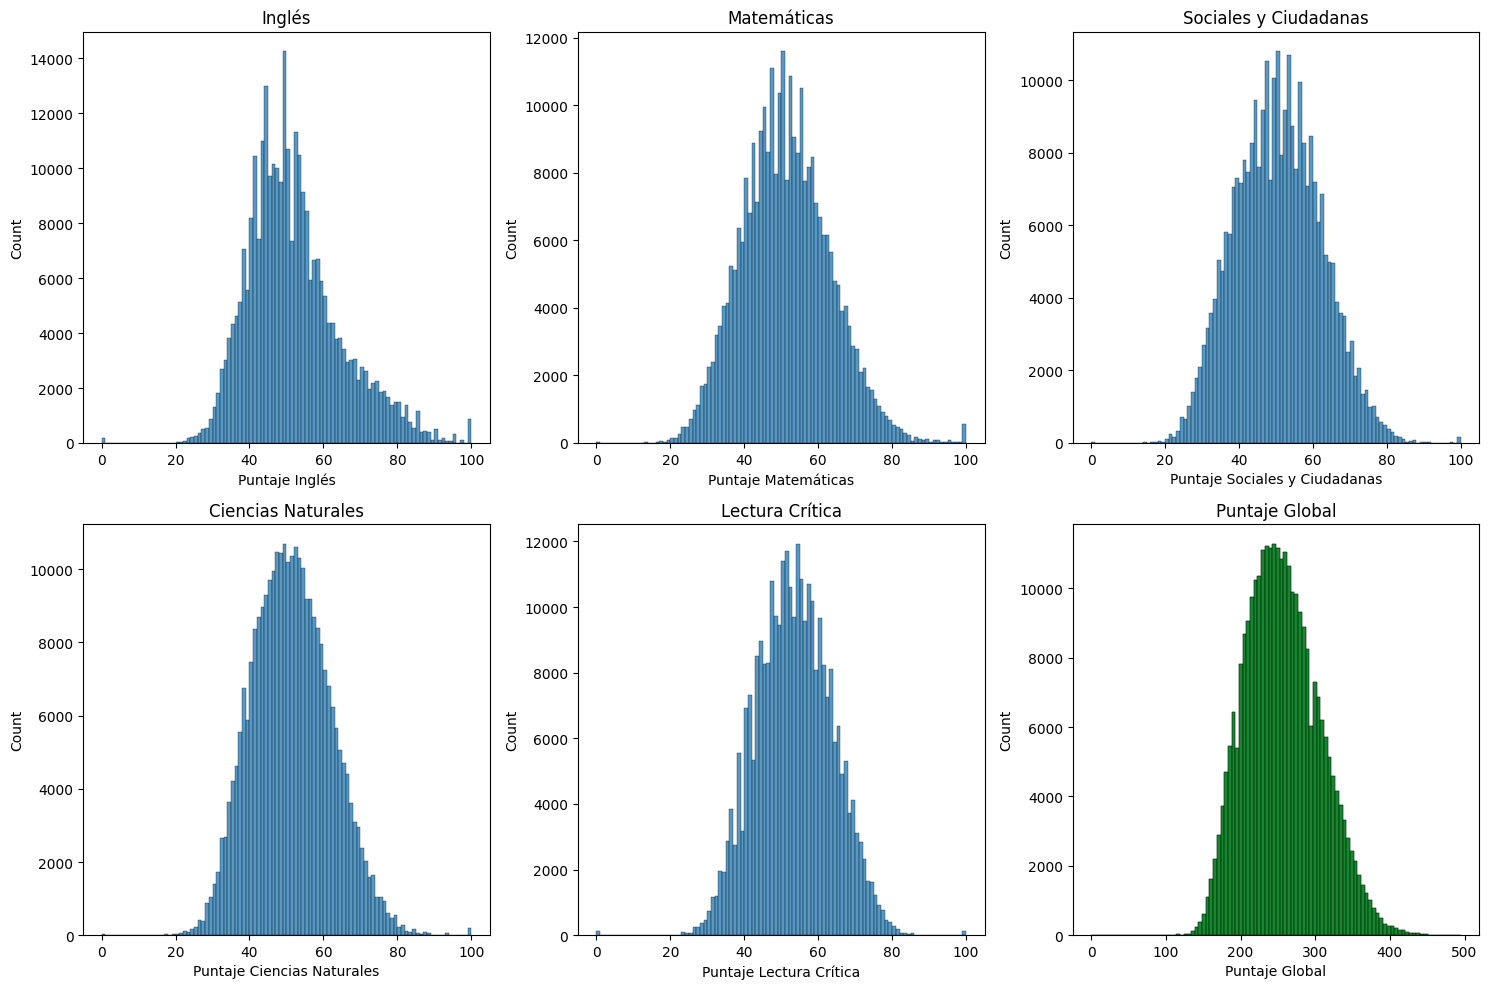

In [202]:
puntajes = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i in range(len(puntajes)):
    sns.histplot(df[puntajes[i]], bins=100, ax=axes[i])
    axes[i].set_title(puntajes[i])

axes[0].set_xlabel("Puntaje Inglés")
axes[0].set_title("Inglés")
axes[1].set_xlabel("Puntaje Matemáticas")
axes[1].set_title("Matemáticas")
axes[2].set_xlabel("Puntaje Sociales y Ciudadanas")
axes[2].set_title("Sociales y Ciudadanas")
axes[3].set_xlabel("Puntaje Ciencias Naturales")
axes[3].set_title("Ciencias Naturales")
axes[4].set_xlabel("Puntaje Lectura Crítica")
axes[4].set_title("Lectura Crítica")
axes[5].set_xlabel("Puntaje Global")
axes[5].set_title("Puntaje Global")

sns.histplot(df[puntajes[5]], bins=100, ax=axes[5], color="green")
plt.tight_layout()
plt.show()

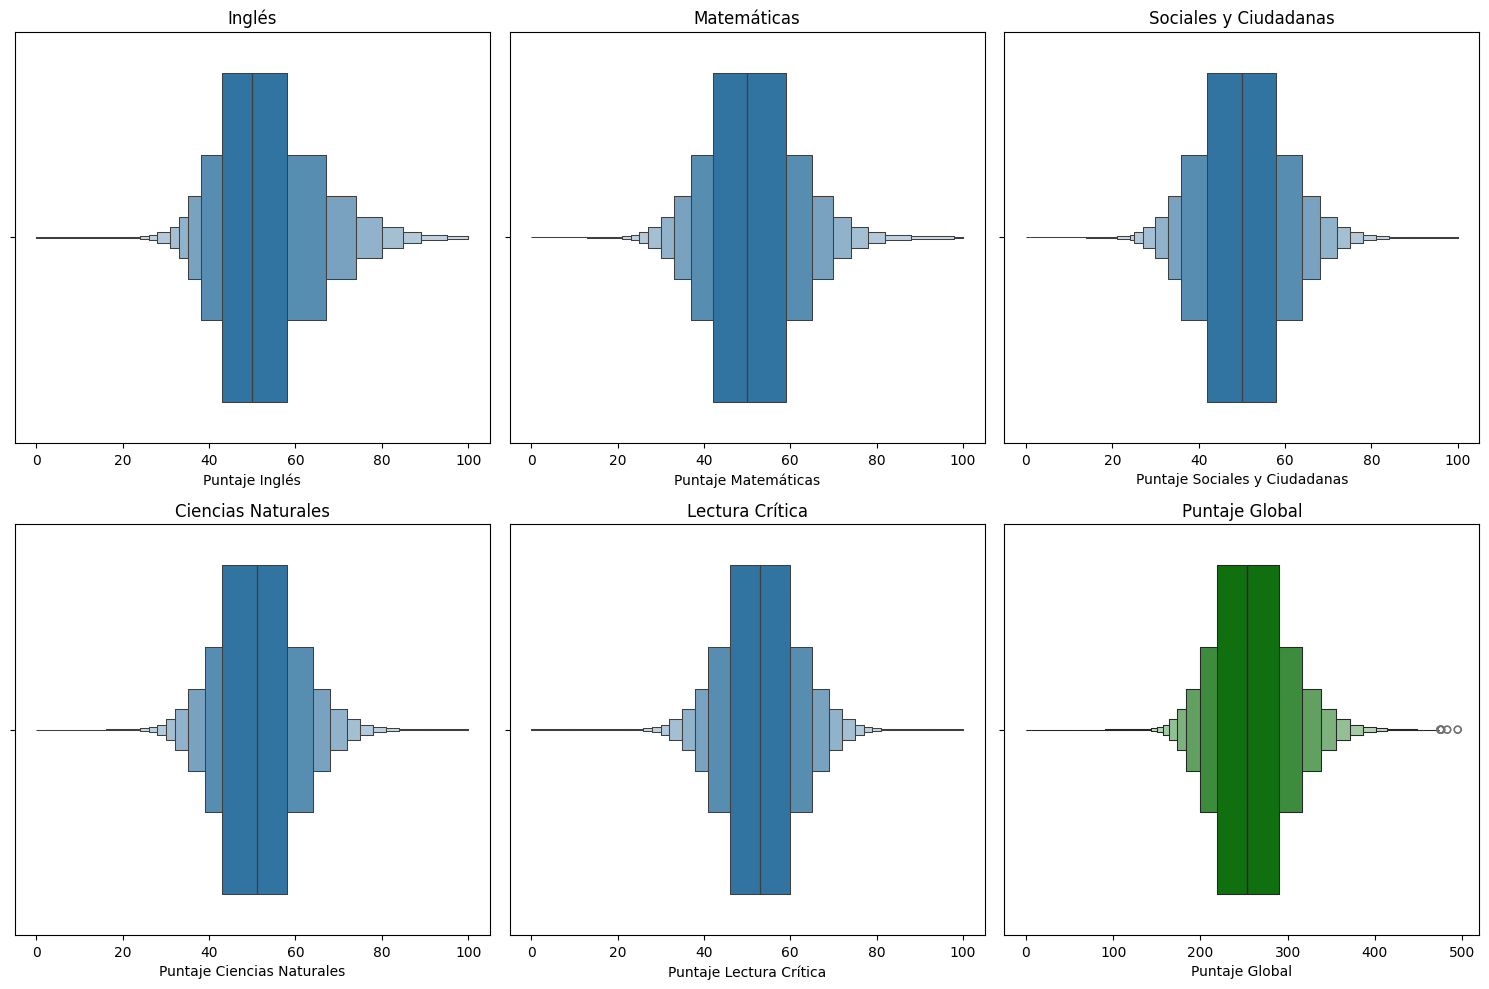

In [203]:
puntajes = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i in range(len(puntajes)):
    sns.boxenplot(x=df[puntajes[i]], ax=axes[i])
    axes[i].set_title(puntajes[i])

axes[0].set_xlabel("Puntaje Inglés")
axes[0].set_title("Inglés")
axes[1].set_xlabel("Puntaje Matemáticas")
axes[1].set_title("Matemáticas")
axes[2].set_xlabel("Puntaje Sociales y Ciudadanas")
axes[2].set_title("Sociales y Ciudadanas")
axes[3].set_xlabel("Puntaje Ciencias Naturales")
axes[3].set_title("Ciencias Naturales")
axes[4].set_xlabel("Puntaje Lectura Crítica")
axes[4].set_title("Lectura Crítica")
axes[5].set_xlabel("Puntaje Global")
axes[5].set_title("Puntaje Global")

sns.boxenplot(x=df[puntajes[5]], ax=axes[5], color="green")
plt.tight_layout()
plt.show()

### Distribución de Estratos


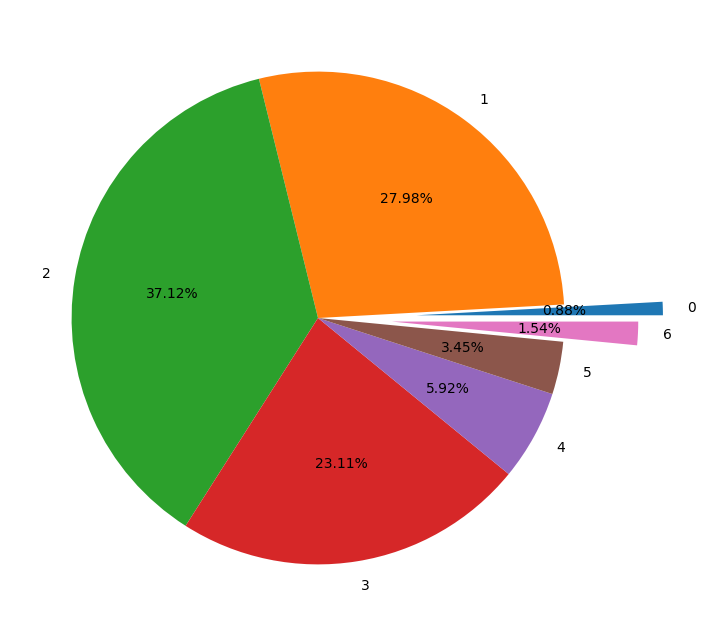

             Cantidad Porcentaje
estrato_num                     
0                2589    0.8771%
1               82588   27.9781%
2              109567   37.1177%
3               68219   23.1104%
4               17485    5.9233%
5               10198    3.4547%
6                4542    1.5387%


In [204]:
cuantas = df["estrato_num"].value_counts().sort_index().to_frame(name="Cantidad")

explode = (0.4, 0, 0, 0, 0, 0, 0.3)

cuantas["Porcentaje"] = (cuantas["Cantidad"] / cuantas["Cantidad"].sum() * 100).round(4).astype(str) + "%"

fig, ax = plt.subplots(figsize=(8,8))
ax.pie(cuantas["Cantidad"], labels=cuantas.index, autopct="%.2f%%", explode=explode)
plt.show()

print(cuantas)

### Personas en el hogar

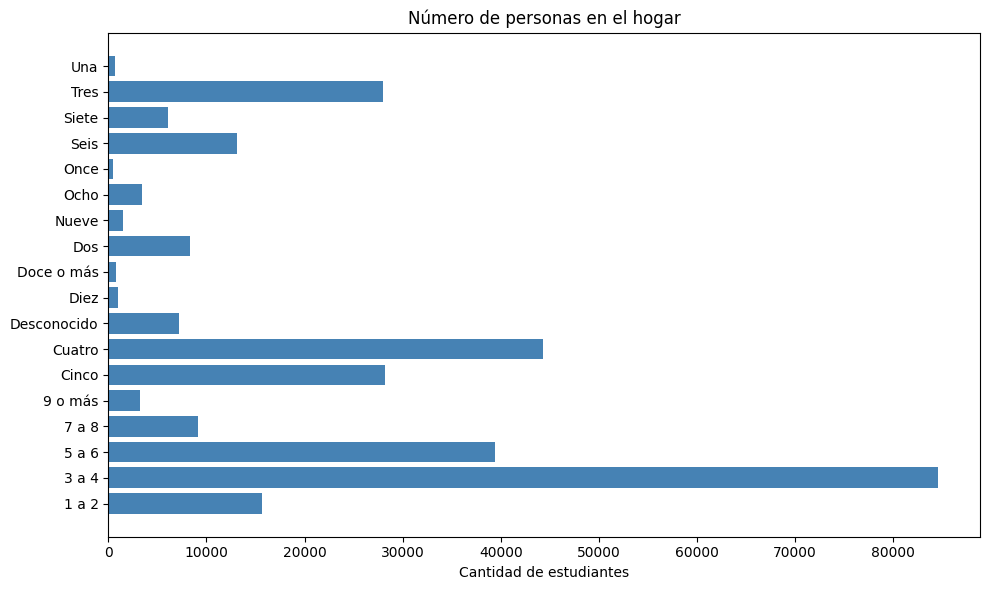

                    Personas Porcentaje
fami_personashogar                     
1 a 2                  15706    5.3207%
3 a 4                  84628   28.6692%
5 a 6                  39381    13.341%
7 a 8                   9141    3.0967%
9 o más                 3236    1.0963%
Cinco                  28215    9.5583%
Cuatro                 44352    15.025%
Desconocido             7225    2.4476%
Diez                    1009    0.3418%
Doce o más               751    0.2544%
Dos                     8365    2.8338%
Nueve                   1509    0.5112%
Ocho                    3401    1.1521%
Once                     439    0.1487%
Seis                   13110    4.4412%
Siete                   6060    2.0529%
Tres                   27950    9.4685%
Una                      710    0.2405%


In [205]:
fig, ax = plt.subplots(figsize=(10,6))

personas = df["fami_personashogar"].value_counts().sort_index().to_frame(name="Personas")
personas["Porcentaje"] = (personas["Personas"] / personas["Personas"].sum() * 100).round(4).astype(str) + "%"
labels = personas.index
valores = personas["Personas"]

bar_pos = range(len(labels))

ax.barh(bar_pos, valores, color="steelblue")

ax.set_yticks(bar_pos, labels)
ax.set_xlabel("Cantidad de estudiantes")
ax.set_title("Número de personas en el hogar")

plt.tight_layout()
plt.show()

print(personas)

### Presentaron en un departamento diferente al Valle


In [206]:

df[df["estu_cod_depto_presentacion"]!=76]
df[df["estu_depto_presentacion"]!="VALLE"] 

df[df["estu_cod_depto_presentacion"]!=76]["estu_depto_presentacion"].value_counts()


estu_depto_presentacion
RISARALDA          266
CAUCA              199
BOGOTÁ             182
CALDAS             176
CASANARE           133
ANTIOQUIA          123
QUINDIO             72
CUNDINAMARCA        66
META                48
TOLIMA              46
NARIÑO              41
HUILA               35
CAQUETA             22
SANTANDER           22
BOYACA              20
SAN ANDRES          20
ATLANTICO           14
VICHADA             11
BOLIVAR             11
ARAUCA              11
CESAR                8
CHOCO                8
PUTUMAYO             8
MAGDALENA            5
SUCRE                4
NORTE SANTANDER      3
CORDOBA              3
GUAVIARE             1
LA GUAJIRA           1
Name: count, dtype: int64

### Viven en un departamento diferente al Valle

In [207]:


df[df["estu_cod_reside_depto"]!=76]

df[df["estu_depto_reside"]!="VALLE"]["estu_depto_reside"].value_counts()



estu_depto_reside
CAUCA              339
CALDAS             261
BOGOTÁ             182
RISARALDA           94
CUNDINAMARCA        52
ANTIOQUIA           50
NARIÑO              44
QUINDIO             38
SANTANDER           20
TOLIMA              17
ATLANTICO           15
CHOCO               15
BOYACA              12
HUILA               12
BOLIVAR              9
META                 8
PUTUMAYO             8
CASANARE             6
CESAR                6
MAGDALENA            5
CAQUETA              5
NORTE SANTANDER      3
CORDOBA              2
SAN ANDRES           1
GUAVIARE             1
AMAZONAS             1
VAUPES               1
SUCRE                1
Name: count, dtype: int64

### Nacionalidades

In [208]:
df["estu_nacionalidad"].value_counts()





estu_nacionalidad
COLOMBIA                  294273
VENEZUELA                    630
ESTADOS UNIDOS                73
ESPAÑA                        54
ECUADOR                       35
FRANCIA                       10
ITALIA                        10
MÉXICO                         9
REINO UNIDO                    8
COSTA RICA                     8
PERÚ                           7
ARGENTINA                      7
NICARAGUA                      5
CHILE                          5
CUBA                           5
PAÍSES BAJOS - HOLANDA         4
HONDURAS                       3
COMORAS                        3
ARUBA                          3
PANAMÁ                         3
JAPÓN                          3
BRASIL                         3
VANUATU                        2
PORTUGAL                       2
GUATEMALA                      2
CANADÁ                         2
AUSTRALIA                      2
BRUNÉI                         2
OMÁN                           1
COSTA DE MARFIL          

Todos viven en el mismo pais en que residen

In [209]:
df[df["estu_nacionalidad"]!=df["estu_pais_reside"]]

,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,estrato_num


In [210]:
df[df["estu_nacionalidad"]!="COLOMBIA"]["estu_depto_reside"].value_counts()




estu_depto_reside
VALLE      914
BOLIVAR      1
Name: count, dtype: int64

# Outliers


In [211]:
df.kurt(numeric_only=True)
puntajes=["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]
for i in puntajes:
    
    print(pd.cut(df[i], bins=10).value_counts().sort_index())


punt_ingles
(-0.1, 10.0]        184
(10.0, 20.0]         75
(20.0, 30.0]       4277
(30.0, 40.0]      46270
(40.0, 50.0]     106087
(50.0, 60.0]      77226
(60.0, 70.0]      33884
(70.0, 80.0]      18793
(80.0, 90.0]       6655
(90.0, 100.0]      1737
Name: count, dtype: int64
punt_matematicas
(-0.1, 10.0]        58
(10.0, 20.0]       386
(20.0, 30.0]      9864
(30.0, 40.0]     47794
(40.0, 50.0]     91689
(50.0, 60.0]     84994
(60.0, 70.0]     44541
(70.0, 80.0]     12881
(80.0, 90.0]      2032
(90.0, 100.0]      949
Name: count, dtype: int64
punt_sociales_ciudadanas
(-0.1, 10.0]        63
(10.0, 20.0]       278
(20.0, 30.0]     11127
(30.0, 40.0]     53620
(40.0, 50.0]     88421
(50.0, 60.0]     85066
(60.0, 70.0]     44382
(70.0, 80.0]     10965
(80.0, 90.0]      1021
(90.0, 100.0]      245
Name: count, dtype: int64
punt_c_naturales
(-0.1, 10.0]        47
(10.0, 20.0]       157
(20.0, 30.0]      4807
(30.0, 40.0]     45159
(40.0, 50.0]     96807
(50.0, 60.0]     91975
(60.0, 70.0] 

In [212]:
for i in puntajes:
    print(df[i].describe())

count    295188.000000
mean         51.636831
std          12.666998
min           0.000000
25%          43.000000
50%          50.000000
75%          58.000000
max         100.000000
Name: punt_ingles, dtype: float64
count    295188.000000
mean         50.880432
std          11.943208
min           0.000000
25%          42.000000
50%          50.000000
75%          59.000000
max         100.000000
Name: punt_matematicas, dtype: float64
count    295188.000000
mean         50.135551
std          11.653442
min           0.000000
25%          42.000000
50%          50.000000
75%          58.000000
max         100.000000
Name: punt_sociales_ciudadanas, dtype: float64
count    295188.000000
mean         50.967343
std          10.731520
min           0.000000
25%          43.000000
50%          51.000000
75%          58.000000
max         100.000000
Name: punt_c_naturales, dtype: float64
count    295188.000000
mean         52.966801
std          10.282470
min           0.000000
25%          

In [213]:
colegios=df.groupby("cole_nombre_establecimiento", as_index=False)[puntajes].mean()

top10_por_categoria = {p: colegios.sort_values(by=p, ascending=False)[["cole_nombre_establecimiento", p]].head(10)for p in puntajes}

for p, tabla in top10_por_categoria.items():
    print(f"\nTop 10 - {p}")
    print(tabla.to_string(index=False))


Top 10 - punt_ingles
          cole_nombre_establecimiento  punt_ingles
                          COL BOLIVAR    86.830870
          COLEGIO BILINGUE DIANA OESE    86.276968
            COLEGIO COLOMBO BRITÁNICO    85.599064
           COLEGIO GIMNASIO LA COLINA    84.764706
                        COL JEFFERSON    84.296935
                      COLEGIO BENNETT    83.302564
   COLEGIO PHILADELPHIA INTERNACIONAL    82.866438
                  ASPAEN LICEO TACURÍ    82.304878
COLEGIO INTERNACIONAL LOS CAÑAVERALES    81.432203
                      COLEGIO FREINET    81.327027

Top 10 - punt_matematicas
        cole_nombre_establecimiento  punt_matematicas
        COLEGIO BILINGUE DIANA OESE         82.125364
 COLEGIO PHILADELPHIA INTERNACIONAL         76.171233
           COLEGIO HISPANOAMERICANO         76.037500
                ASPAEN LICEO TACURÍ         72.530488
          COLEGIO COLOMBO BRITÁNICO         72.313573
                        COL BOLIVAR         72.224959
         COL

## Aberrantes

In [214]:
for i in puntajes:
    #print(df[i].value_counts().sort_index(ascending=True))
    print(f"Variable: {i}")
    print(df[i].unique()[:500])
#df["punt_global"].unique()[:500]

Variable: punt_ingles
[ 54.  44.  64.  46.  39.  50.  52.  49.  40.  38.  48.  35.  34.  53.
  63.  36.  51.  33.  55.  47.  42.  59.  58.  41.  67.  45.  32.  57.
  62.  60.  37. 100.  70.  65.  66.  43.  56.  73.  79.  74.  31.  29.
  68.  30.  75.  69.  76.  82.  61.  72.  71.  77.  78.  81.  83.  28.
  80.  94.  86.  85.  27.  95.  26.  84.  15.  87.  88.  97.  22.   0.
  24.  23.  92.  93.  14.  20.  89.  90.  99.  25.  91.  21.  18.   6.
  98.   7.  19.  96.  16.  13.]
Variable: punt_matematicas
[ 48.  52.  54.  43.  19.  45.  61.  57.  28.  35.  37.  51.  64.  49.
  56.  30.  46.  42.  53.  40.  41.  38.  50.  39.  47.  60.  72.  59.
  32.  71.  24.  36.  62.  69.  65.  63.  34.  33.  70.  31.  55.  58.
  66.  68.  44.  21.  25.  23.  29.  67. 100.  26.  79.  76.  75.  27.
  20.  78.  77.  74.  80.  73.  17.  22.  92.  83.  81.   0.   1.  82.
  86.  84.  87.  99.  88.  95.   7.  12.  85.  89.  18.  91.  90.  98.
  16.  96.  15.  93.  97.  94.   8.  13.  11.  10.]
Variable: punt_

In [215]:
categorias= df.columns.tolist()
df["estu_cod_reside_depto"].replace({'VALLE': 76}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'CALI': 76001}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'GUADALAJARA DE BUGA': 76111}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'BUGALAGRANDE': 76113}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'EL CERRITO': 76248}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'JAMUNDÍ': 76364}, inplace=True)
df["estu_cod_reside_mcpio"].replace({'YUMBO': 76892}, inplace=True)

for i in categorias:
    #print(df[i].value_counts().sort_index(ascending=True))
    print(f"Variable: {i}")
    print(df[i].unique()[:1000])



Variable: periodo
[20224 20162 20142 20194 20211 20172 20161 20181 20152 20201 20191 20171
 20151 20221]
Variable: estu_tipodocumento
['TI' 'CC' 'NES' 'CE' 'CR' 'PEP' 'PPT' 'PE' 'PC' 'RC' 'PET']
Variable: estu_consecutivo
['SB11202240052447' 'SB11202240057782' 'SB11202240151458'
 'SB11202240225511' 'SB11202240427250' 'SB11202240085624'
 'SB11202240282733' 'SB11202240167237' 'SB11202240080544'
 'SB11202240358675' 'SB11202240306684' 'SB11202240255965'
 'SB11202240112660' 'SB11202240554247' 'SB11202240191367'
 'SB11202240174269' 'SB11202240099983' 'SB11202240053763'
 'SB11202240576774' 'SB11202240138462' 'SB11202240071927'
 'SB11202240110551' 'SB11202240222637' 'SB11202240163311'
 'SB11202240169017' 'SB11202240196630' 'SB11202240248601'
 'SB11202240231569' 'SB11202240168171' 'SB11202240191933'
 'SB11202240292156' 'SB11202240224472' 'SB11202240083784'
 'SB11202240524158' 'SB11202240562428' 'SB11202240320785'
 'SB11202240103973' 'SB11202240516890' 'SB11202240255237'
 'SB11202240018715' 'SB1